In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully!")

All libraries imported successfully!


In [8]:
df = pd.read_csv('../Data/diabetes.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.describe().round(2)

Shape: (253680, 22)
Columns: ['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,...,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00
mean,0.14,0.43,0.42,0.96,28.38,0.44,0.04,0.09,0.76,0.63,...,0.95,0.08,2.51,3.18,4.24,0.17,0.44,8.03,5.05,6.05
std,0.35,0.49,0.49,0.19,6.61,0.50,0.20,0.29,0.43,0.48,...,0.22,0.28,1.07,7.41,8.72,0.37,0.50,3.05,0.99,2.07
min,0.00,0.00,0.00,0.00,12.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00
25%,0.00,0.00,0.00,1.00,24.00,0.00,0.00,0.00,1.00,0.00,...,1.00,0.00,2.00,0.00,0.00,0.00,0.00,6.00,4.00,5.00
50%,0.00,0.00,0.00,1.00,27.00,0.00,0.00,0.00,1.00,1.00,...,1.00,0.00,2.00,0.00,0.00,0.00,0.00,8.00,5.00,7.00
75%,0.00,1.00,1.00,1.00,31.00,1.00,0.00,0.00,1.00,1.00,...,1.00,0.00,3.00,2.00,3.00,0.00,1.00,10.00,6.00,8.00
max,1.00,1.00,1.00,1.00,98.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,5.00,30.00,30.00,1.00,1.00,13.00,6.00,8.00


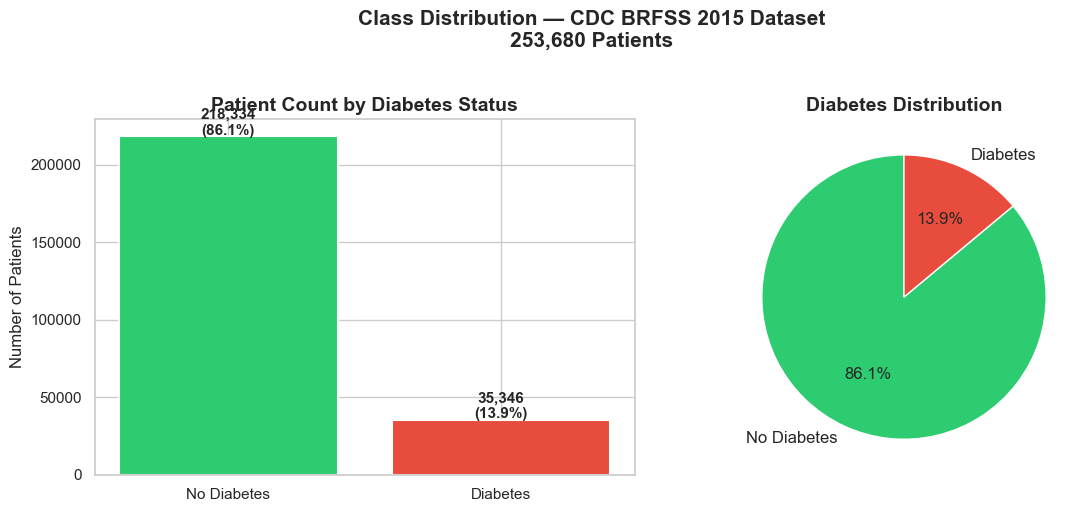

Chart saved to reports folder!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['Diabetes_binary'].value_counts()
labels = ['No Diabetes', 'Diabetes']
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Patient Count by Diabetes Status', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Diabetes Distribution', fontsize=14, fontweight='bold')

plt.suptitle('Class Distribution — CDC BRFSS 2015 Dataset\n253,680 Patients',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports folder!")

Average BMI:
  No Diabetes : 27.8
  Diabetes    : 31.9


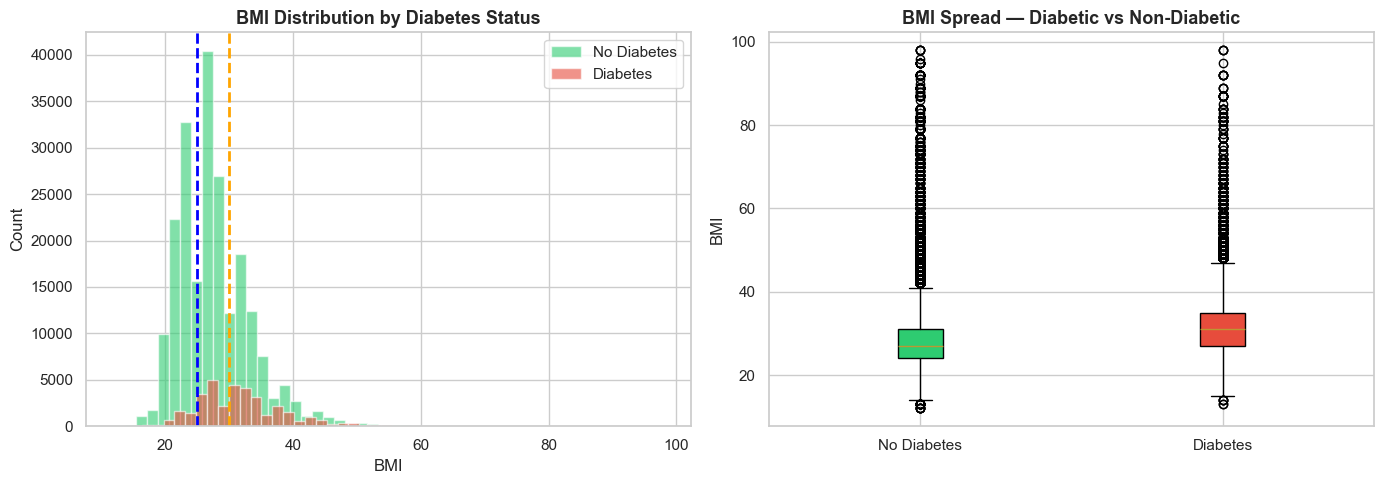

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['Diabetes_binary']==0]['BMI'].plot.hist(
    bins=50, alpha=0.6, color='#2ecc71', label='No Diabetes', ax=axes[0])
df[df['Diabetes_binary']==1]['BMI'].plot.hist(
    bins=50, alpha=0.6, color='#e74c3c', label='Diabetes', ax=axes[0])
axes[0].set_title('BMI Distribution by Diabetes Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Count')
axes[0].axvline(x=25, color='blue', linestyle='--', linewidth=2)
axes[0].axvline(x=30, color='orange', linestyle='--', linewidth=2)
axes[0].legend()

data_to_plot = [df[df['Diabetes_binary']==0]['BMI'].values,
                df[df['Diabetes_binary']==1]['BMI'].values]
bp = axes[1].boxplot(data_to_plot, labels=['No Diabetes', 'Diabetes'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_title('BMI Spread — Diabetic vs Non-Diabetic', fontsize=13, fontweight='bold')
axes[1].set_ylabel('BMI')

print("Average BMI:")
print(f"  No Diabetes : {df[df['Diabetes_binary']==0]['BMI'].mean():.1f}")
print(f"  Diabetes    : {df[df['Diabetes_binary']==1]['BMI'].mean():.1f}")

plt.tight_layout()
plt.savefig('../reports/02_bmi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

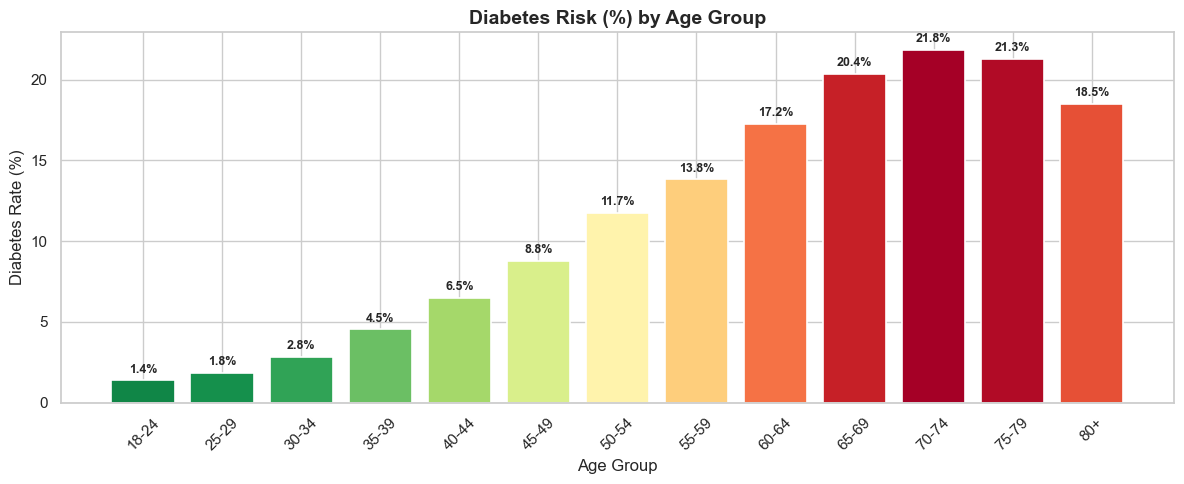

Lowest risk age group  : 18-24 (1.4%)
Highest risk age group : 70-74 (21.8%)


In [11]:
age_labels = {1:'18-24', 2:'25-29', 3:'30-34', 4:'35-39', 5:'40-44',
              6:'45-49', 7:'50-54', 8:'55-59', 9:'60-64', 10:'65-69',
              11:'70-74', 12:'75-79', 13:'80+'}

age_risk = df.groupby('Age')['Diabetes_binary'].mean() * 100
age_risk.index = [age_labels[i] for i in age_risk.index]

plt.figure(figsize=(12, 5))
bars = plt.bar(age_risk.index, age_risk.values,
               color=plt.cm.RdYlGn_r(age_risk.values / age_risk.max()),
               edgecolor='white', linewidth=1.2)
plt.title('Diabetes Risk (%) by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Diabetes Rate (%)')
plt.xticks(rotation=45)
for bar, val in zip(bars, age_risk.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/03_age_diabetes_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Lowest risk age group  : {age_risk.idxmin()} ({age_risk.min():.1f}%)")
print(f"Highest risk age group : {age_risk.idxmax()} ({age_risk.max():.1f}%)")

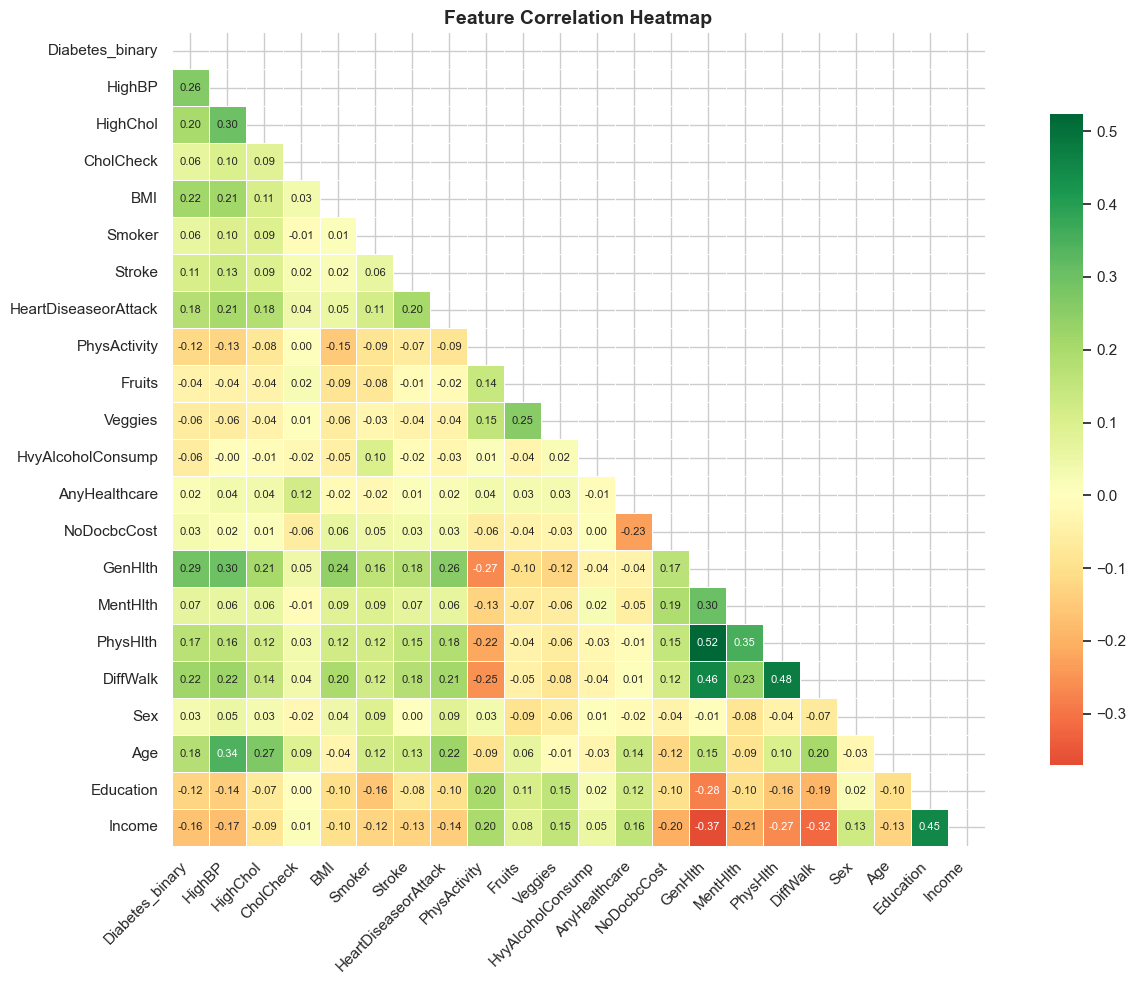

Top 5 features most correlated with Diabetes:
  GenHlth                   : 0.294
  HighBP                    : 0.263
  DiffWalk                  : 0.218
  BMI                       : 0.217
  HighChol                  : 0.200


In [12]:
plt.figure(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            annot_kws={"size": 8})

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

top_corr = corr['Diabetes_binary'].drop('Diabetes_binary').abs().sort_values(ascending=False).head(5)
print("Top 5 features most correlated with Diabetes:")
for feat, val in top_corr.items():
    print(f"  {feat:<25} : {val:.3f}")

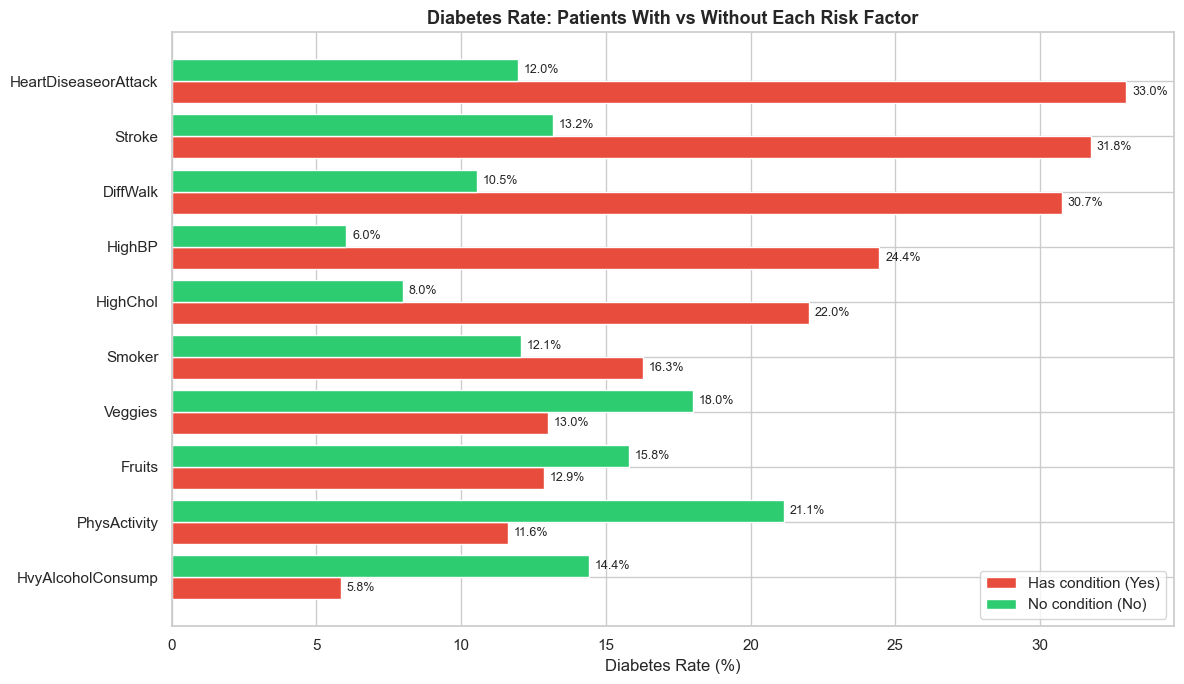

In [13]:
risk_features = ['HighBP', 'HighChol', 'Smoker', 'Stroke',
                 'HeartDiseaseorAttack', 'PhysActivity',
                 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'DiffWalk']

risk_data = []
for feature in risk_features:
    rate_yes = df[df[feature]==1]['Diabetes_binary'].mean() * 100
    rate_no  = df[df[feature]==0]['Diabetes_binary'].mean() * 100
    risk_data.append({'Feature': feature, 'Has condition': rate_yes, 'No condition': rate_no})

risk_df = pd.DataFrame(risk_data).sort_values('Has condition', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
x = range(len(risk_df))
bars1 = ax.barh([i-0.2 for i in x], risk_df['Has condition'],
                 height=0.4, color='#e74c3c', label='Has condition (Yes)')
bars2 = ax.barh([i+0.2 for i in x], risk_df['No condition'],
                 height=0.4, color='#2ecc71', label='No condition (No)')
ax.set_yticks(list(x))
ax.set_yticklabels(risk_df['Feature'])
ax.set_xlabel('Diabetes Rate (%)')
ax.set_title('Diabetes Rate: Patients With vs Without Each Risk Factor',
             fontsize=13, fontweight='bold')
ax.legend()
for bar in bars1:
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/05_risk_factors.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
print("=" * 55)
print("  KEY INSIGHTS — MEMORISE THESE FOR YOUR INTERVIEW")
print("=" * 55)

avg_bmi_no  = df[df['Diabetes_binary']==0]['BMI'].mean()
avg_bmi_yes = df[df['Diabetes_binary']==1]['BMI'].mean()
highbp_rate = df[df['HighBP']==1]['Diabetes_binary'].mean()*100
stroke_rate = df[df['Stroke']==1]['Diabetes_binary'].mean()*100
oldest_risk = df[df['Age']==13]['Diabetes_binary'].mean()*100
youngest    = df[df['Age']==1]['Diabetes_binary'].mean()*100

print(f"1. Dataset    : 253,680 patients, 21 features, 0 missing values")
print(f"2. Imbalance  : 86.1% no diabetes  vs  13.9% diabetes")
print(f"3. BMI        : Diabetic avg = {avg_bmi_yes:.1f}  vs  Non-diabetic avg = {avg_bmi_no:.1f}")
print(f"4. Blood Pres : {highbp_rate:.1f}% of high BP patients have diabetes")
print(f"5. Stroke     : {stroke_rate:.1f}% of stroke patients also have diabetes")
print(f"6. Age risk   : {youngest:.1f}% in 18-24 group  vs  {oldest_risk:.1f}% in 80+ group")
print(f"7. Top feats  : GenHlth, HighBP, DiffWalk, BMI, HighChol")
print(f"8. Source     : CDC BRFSS 2015 — real government health survey data")
print("=" * 55)

  KEY INSIGHTS — MEMORISE THESE FOR YOUR INTERVIEW
1. Dataset    : 253,680 patients, 21 features, 0 missing values
2. Imbalance  : 86.1% no diabetes  vs  13.9% diabetes
3. BMI        : Diabetic avg = 31.9  vs  Non-diabetic avg = 27.8
4. Blood Pres : 24.4% of high BP patients have diabetes
5. Stroke     : 31.8% of stroke patients also have diabetes
6. Age risk   : 1.4% in 18-24 group  vs  18.5% in 80+ group
7. Top feats  : GenHlth, HighBP, DiffWalk, BMI, HighChol
8. Source     : CDC BRFSS 2015 — real government health survey data
